In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install torchinfo
!pip install torchmetrics
!pip install mlflow
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [3]:
import sys
sys.path.append('/content/drive/My Drive/Deep Learning Projects/Autonomous driving semantic segmentation/')

In [4]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchmetrics.segmentation import DiceScore

import mlflow
import mlflow.pytorch

import numpy as np
import matplotlib.pyplot as plt
from src import model, engine
from src.architectures import unet, deeplabv3_plus
from src.model import get_model

import yaml


import albumentations as A
from albumentations.pytorch import ToTensorV2

from PIL import Image

import os
import shutil
import zipfile

In [7]:
ZIP_PATH = "/content/drive/My Drive/Deep Learning Projects/Autonomous driving semantic segmentation/data/carla_dataset.zip"
EXTRACT_PATH = "/content/drive/My Drive/Deep Learning Projects/Autonomous driving semantic segmentation/data/carla_dataset"

def unzip_data(zip_path, extract_to):
    target = os.path.join(extract_to, "carla_dataset")

    os.makedirs(extract_to, exist_ok=True)
    if not os.path.exists(target):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_to)
    else:
        print("Already extracted")

In [6]:
# unzip_data(ZIP_PATH, EXTRACT_PATH)

In [8]:
with open("/content/drive/MyDrive/Deep Learning Projects/Autonomous driving semantic segmentation/configs/model_config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [9]:
class CarlaDataset(Dataset):
    def __init__(self, img_dirs, transform=None):
        self.transform = transform
        self.samples = []

        for d in img_dirs:
            rgb_dir = os.path.join(d, "CameraRGB")
            seg_dir = os.path.join(d, "CameraSeg")

            images = sorted(os.listdir(rgb_dir))
            masks = sorted(os.listdir(seg_dir))

            for img_name, mask_name in zip(images, masks):
                self.samples.append((
                    os.path.join(rgb_dir, img_name),
                    os.path.join(seg_dir, mask_name)
                ))

    def __len__(self):
        return len(self.samples)

    def process_mask(self, mask):
        return mask[:, :, 0]

    def __getitem__(self, index):
        img_path, mask_path = self.samples[index]

        img = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))


        mask = self.process_mask(mask)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]

        return img, mask.long()

In [10]:
data_dir = ['/content/drive/My Drive/Deep Learning Projects/Autonomous driving semantic segmentation/data/carla_dataset/data'+i+'/data'+i for i in ['A','B','C','D','E']]

sample_data_dir = ['/content/drive/My Drive/Deep Learning Projects/Autonomous driving semantic segmentation/data/sample_data']

In [11]:
transform = A.Compose([
    A.RandomResizedCrop(size=(256, 256), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.GridDistortion(p=0.2),
    A.ElasticTransform(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], additional_targets={'mask': 'mask'})

In [12]:
def get_dataloaders(image_dir, batch_size, num_workers, transform=None, pin_memory=True):
    data = CarlaDataset(img_dirs=image_dir, transform=transform)
    train_size = int(0.8 * data.__len__())
    test_size = data.__len__() - train_size
    train_set, test_set = torch.utils.data.random_split(data, [train_size, test_size])
    train_batch = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, pin_memory=pin_memory)
    test_batch = DataLoader(test_set, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=pin_memory)

    return train_batch, test_batch

In [14]:
train_batch, test_batch = get_dataloaders(data_dir, config['batch_size'], config['num_workers'], transform=transform)

In [13]:
len(train_batch)

500

In [14]:
it = iter(train_batch)

for i in range(5):
    image, mask = next(it)
    print(f"Image tensor: {image}")
    print(f"Image shape: {image.shape}")

Image tensor: tensor([[[[-0.0801, -0.0629, -0.0458,  ..., -0.2684, -0.6109, -0.6109],
          [-0.0801, -0.0801, -0.0629,  ..., -0.7137, -1.6384, -1.6384],
          [-0.0801, -0.0801, -0.0629,  ..., -1.4158, -1.7583, -1.7583],
          ...,
          [-1.9638, -2.0837, -2.0665,  ..., -2.1179, -2.1179, -2.1179],
          [-1.9980, -2.0665, -2.0665,  ..., -2.0837, -2.1179, -2.1179],
          [-1.9980, -2.0665, -2.0665,  ..., -2.0837, -2.1179, -2.1179]],

         [[ 0.3452,  0.3627,  0.3803,  ...,  0.2577, -0.1975, -0.1975],
          [ 0.3452,  0.3452,  0.3803,  ..., -0.3200, -1.4755, -1.4755],
          [ 0.3627,  0.3627,  0.3803,  ..., -1.3004, -1.6856, -1.6856],
          ...,
          [-1.8606, -1.8782, -1.8431,  ..., -2.0357, -2.0007, -2.0007],
          [-1.8256, -1.9132, -1.8431,  ..., -2.0007, -2.0357, -2.0357],
          [-1.8256, -1.9132, -1.8431,  ..., -2.0007, -2.0357, -2.0357]],

         [[ 0.8622,  0.8797,  0.8797,  ...,  0.8797,  0.3045,  0.3045],
          [ 0.86

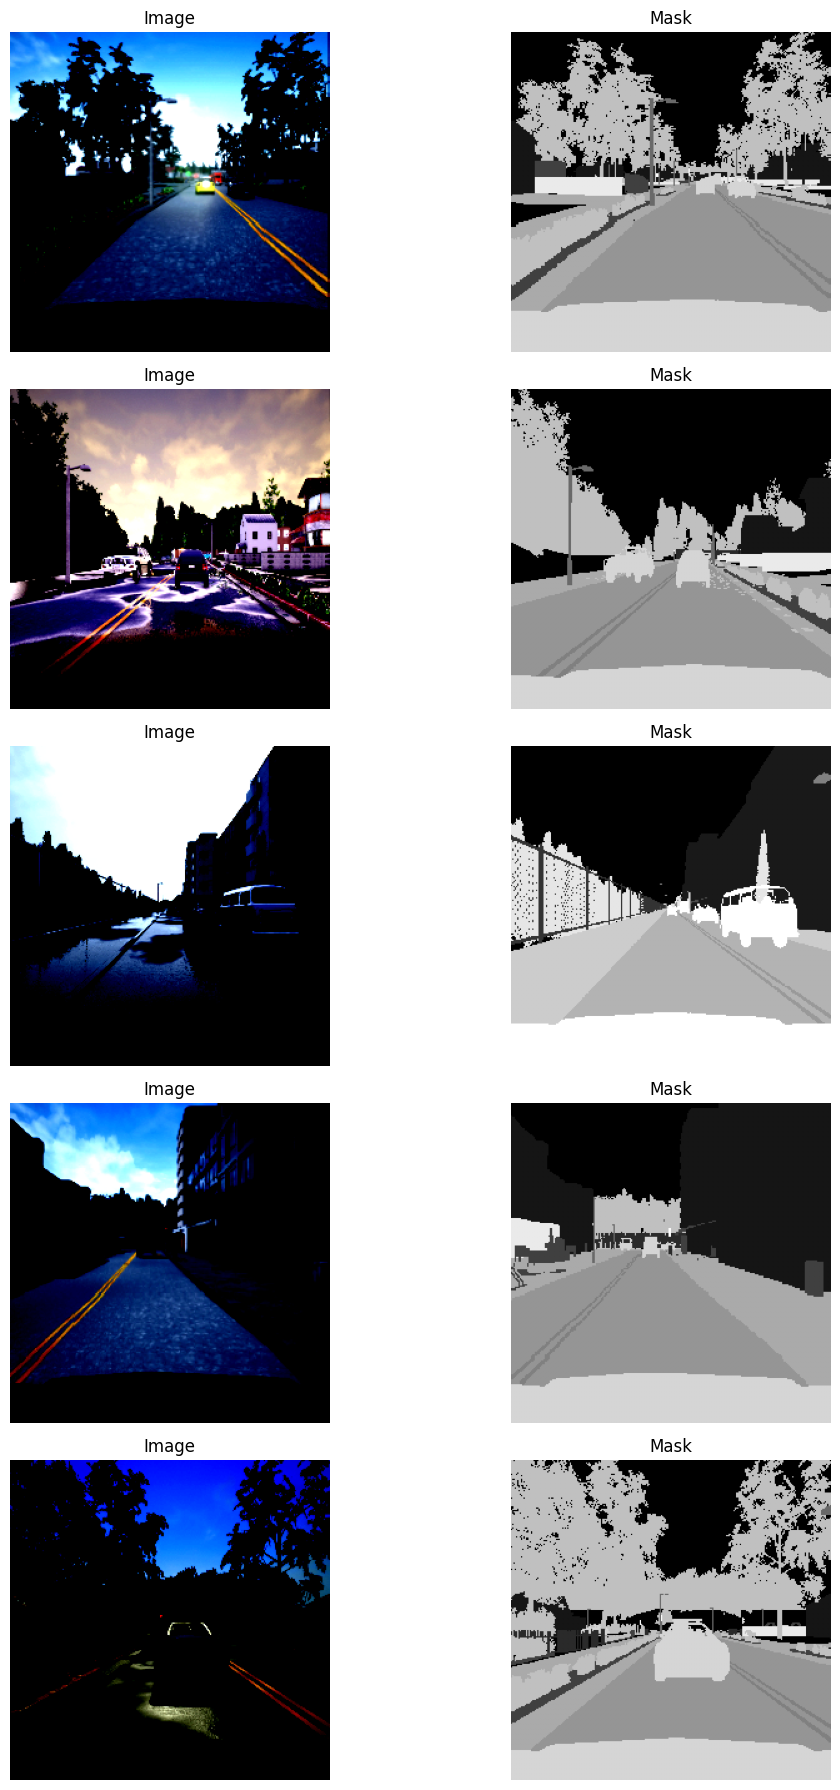

In [15]:
it = iter(train_batch)
images, masks = next(it)

fig, ax = plt.subplots(5, 2, figsize=(12, 18))

for i in range(5):
    img = images[i].permute(1, 2, 0).cpu().numpy()   # (H, W, C)
    msk = masks[i].cpu().numpy()

    ax[i, 0].imshow(img)
    ax[i, 0].set_title("Image")
    ax[i, 0].axis("off")

    ax[i, 1].imshow(msk, cmap="gray")
    ax[i, 1].set_title("Mask")
    ax[i, 1].axis("off")


plt.tight_layout()
plt.show()

## Architecture

In [22]:
unet_model = unet.UNet()
unet_model = unet_model.to(config['device'])

In [17]:
summary(unet_model)

Layer (type:depth-idx)                   Param #
UNet                                     --
├─ConvBlock: 1-1                         --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─BatchNorm2d: 3-2             128
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  36,928
│    │    └─BatchNorm2d: 3-5             128
│    │    └─ReLU: 3-6                    --
│    └─MaxPool2d: 2-2                    --
├─ConvBlock: 1-2                         --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-7                  73,856
│    │    └─BatchNorm2d: 3-8             256
│    │    └─ReLU: 3-9                    --
│    │    └─Conv2d: 3-10                 147,584
│    │    └─BatchNorm2d: 3-11            256
│    │    └─ReLU: 3-12                   --
│    └─MaxPool2d: 2-4                    --
├─ConvBlock: 1-3                         --
│    └─Sequential: 2-5                   --
│    │ 

## Loss Functions & Training

In [18]:
optimizer = torch.optim.AdamW(params=unet_model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3)

loss_fn = torch.nn.CrossEntropyLoss()
accuracy_fn = DiceScore(
    num_classes=13,
    include_background=True,
    input_format='index').to(config['device'])

In [19]:
mlflow.set_tracking_uri("/content/drive/MyDrive/Deep Learning Projects/Autonomous driving semantic segmentation/mlruns")

mlflow.set_experiment("AD_segmentation")

# mlflow.end_run()

# Run mlflow
with mlflow.start_run(run_name="UNet"):

    mlflow.log_param("model", "Unet")
    mlflow.log_param("batch_size", config['batch_size'])
    mlflow.log_param("learning_rate", 3e-4)
    mlflow.log_param("epochs", 50)

    results = engine.train(
      unet_model,
      train_batch,
      test_batch,
      optimizer,
      loss_fn,
      accuracy_fn,
      scheduler,
      device=config['device'],
      epochs=50
   )

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6071 | train_acc: 0.4476 | test_loss: 0.3556 |test_acc: 0.5114 | LR: 0.000300
Epoch: 2 | train_loss: 0.3145 | train_acc: 0.5392 | test_loss: 0.2984 |test_acc: 0.5509 | LR: 0.000300
Epoch: 3 | train_loss: 0.2679 | train_acc: 0.5803 | test_loss: 0.2496 |test_acc: 0.5974 | LR: 0.000300
Epoch: 4 | train_loss: 0.2424 | train_acc: 0.6123 | test_loss: 0.2329 |test_acc: 0.6081 | LR: 0.000300
Epoch: 5 | train_loss: 0.2249 | train_acc: 0.6366 | test_loss: 0.2101 |test_acc: 0.6547 | LR: 0.000300
Epoch: 6 | train_loss: 0.2149 | train_acc: 0.6533 | test_loss: 0.2092 |test_acc: 0.6689 | LR: 0.000300
Epoch: 7 | train_loss: 0.2045 | train_acc: 0.6689 | test_loss: 0.2009 |test_acc: 0.6788 | LR: 0.000300
Epoch: 8 | train_loss: 0.2042 | train_acc: 0.6728 | test_loss: 0.2030 |test_acc: 0.6648 | LR: 0.000300
Epoch: 9 | train_loss: 0.1932 | train_acc: 0.6867 | test_loss: 0.2165 |test_acc: 0.6546 | LR: 0.000300
Epoch: 10 | train_loss: 0.1891 | train_acc: 0.6938 | test_loss: 0.1859 |t

In [20]:
# Save model
torch.save(unet_model.state_dict(), "/content/drive/MyDrive/Deep Learning Projects/Autonomous driving semantic segmentation/models/unet.pth")

In [30]:
# Load state_dict to our model
unet_model.load_state_dict(torch.load("/content/drive/MyDrive/Deep Learning Projects/Autonomous driving semantic segmentation/models/unet.pth", map_location=config['device']))
unet_model.to(config['device'])


UNet(
  (input_block): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (downsample_block1): ConvBlock(
    (conv_block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

## Visualize Predictions

In [27]:
def visualize_predictions(model, dataloader, device="cuda", num_samples = 10):
    model.eval()
    plt.figure(figsize=(15, num_samples*5))

    data_iter = iter(dataloader)

    for i in range(num_samples):
        images, masks = next(data_iter)

        image = images[0].to(device)
        mask = masks[0]

        with torch.no_grad():
            pred = model(image.unsqueeze(0))
            pred = torch.argmax(pred, dim=1).squeeze(0)

        image_np = image.cpu().permute(1, 2, 0).numpy()
        mask_np = mask.cpu().numpy()
        pred_np = pred.cpu().numpy()

        plt.subplot(num_samples, 3, i*3+1)
        plt.imshow(image_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3+2)
        plt.imshow(mask_np)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3+3)
        plt.imshow(pred_np)
        plt.title("Prediction mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

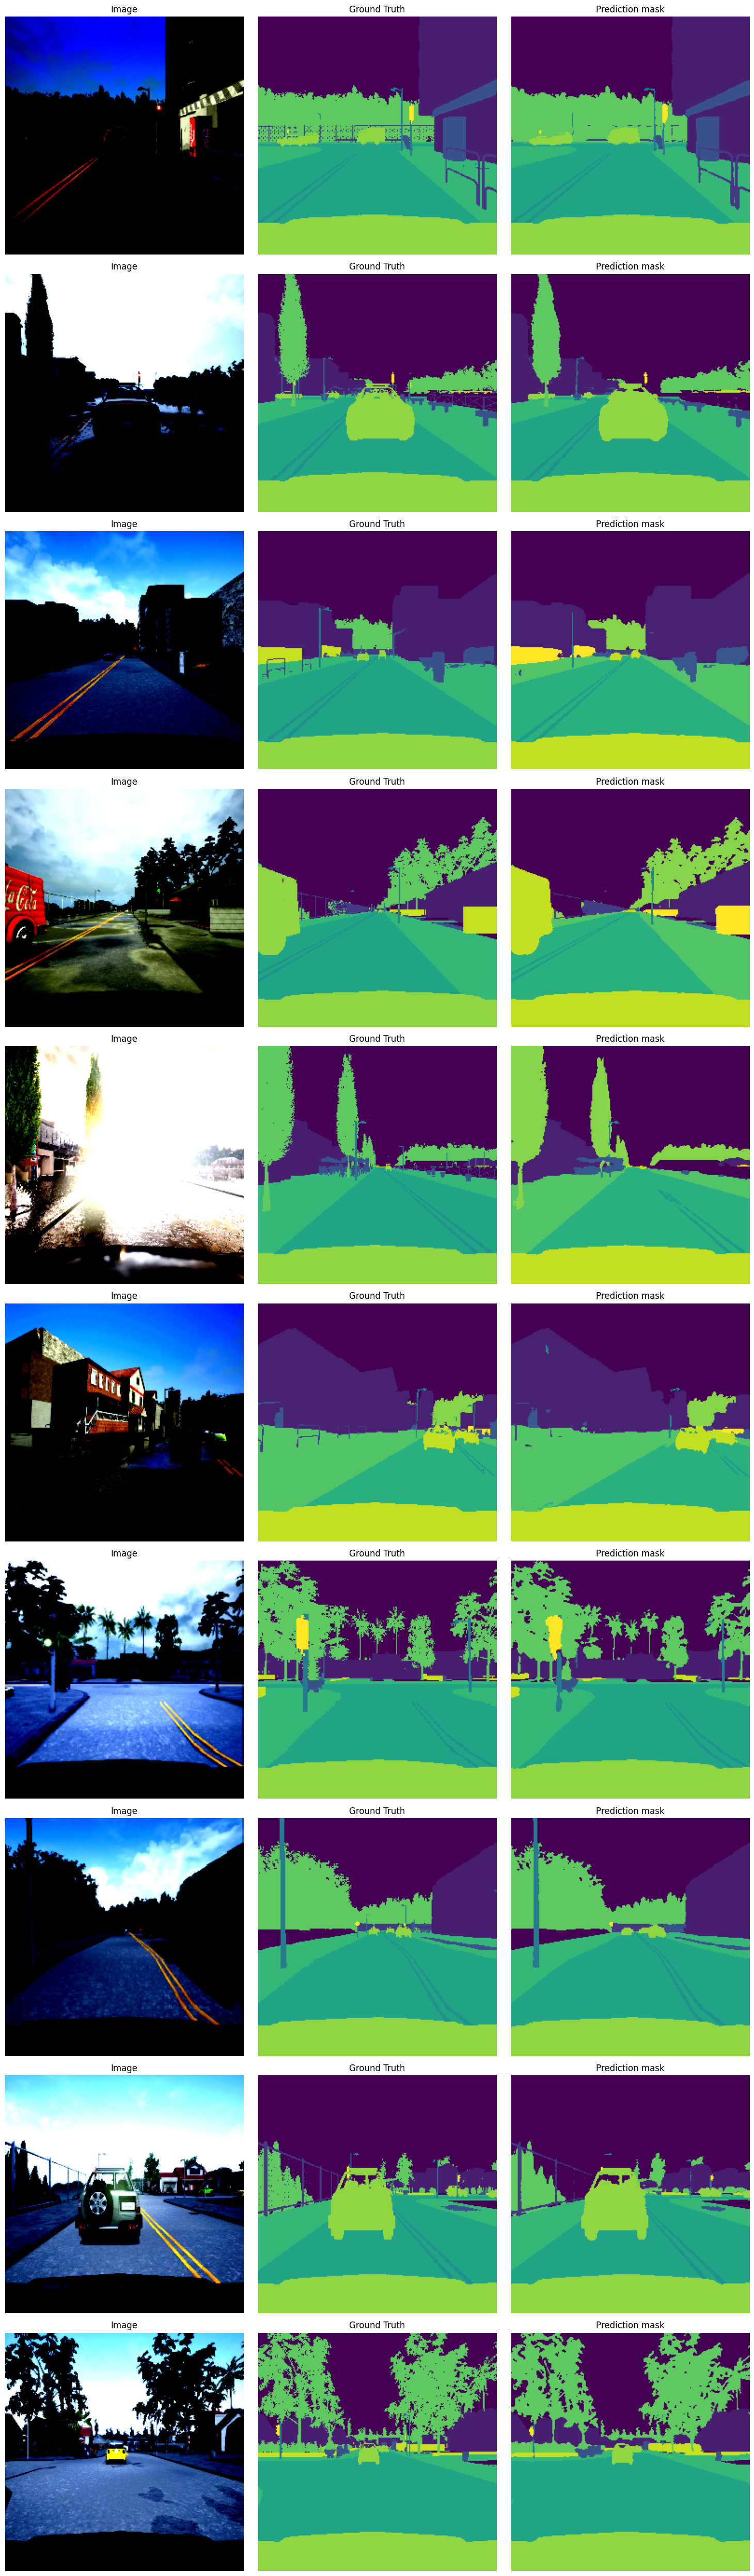

In [31]:
visualize_predictions(unet_model, test_batch, device=config['device'])